# Stage 23 — Experiment A: Attention-Weighted Prototype Loss

Trains `ProtoSegNet(proto_levels=[1,2,3,4], use_level_attention=True)` with per-level
prototype losses scaled by their attention weight.

**Hypothesis (RQ6):** Weighting prototype losses by attention weight eliminates gradient
contamination from L1/L2 into the encoder, recovering L4 purity and AP.

Key difference from M4-attn (λ=0) noent baseline:
- Instead of uniform `criterion(logits, lbls, hm)` for all levels,
  each level's div/push/pull loss is scaled by `w_l.mean().detach()` before summing.
- `w_l` is detached — attention MLP does not receive gradient from prototype losses.

Baselines:
- **M4 (max)**:       3D Dice 0.8407, Purity L4 0.824, AP L4 0.189
- **M4-attn λ=0**:  3D Dice 0.8416, Purity L4 0.537, AP L4 0.085  ← direct baseline
- **M2 (max)**:       3D Dice 0.8722, Purity L4 0.804, AP L4 0.236  ← ceiling

## 0. Config

In [ ]:
import sys, os

_root = (
    os.path.dirname(os.getcwd())
    if os.path.basename(os.getcwd()) == "notebooks"
    else os.getcwd()
)
os.chdir(_root)
sys.path.insert(0, _root)
os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "0.0")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

# ── Attention config ──────────────────────────────────────────────────────────
PROTO_LEVELS = [1, 2, 3, 4]  # full multi-scale — same as M4
USE_LEVEL_ATTENTION = True
WEIGHTED_PROTO_LOSS = True  # Exp A: per-level prototype loss weighted by attn weight
MODALITY = "ct"
SUFFIX = "_l1234_attn_wloss"

# ── Hyperparameters (same as noent baseline) ─────────────────────────────────
LAMBDA_ENT = 0.0  # no entropy reg — same as noent
ATTN_WARMUP_EPOCHS = 10  # epochs into Phase B before attention is unfrozen
LAMBDA_DIV = 0.001
LAMBDA_PUSH = 0.5
LAMBDA_PULL = 0.25
BATCH_SIZE = 16
LR = 3e-4
WEIGHT_DECAY = 1e-5
PHASE_A_END = 20
PHASE_B_END = 80
PHASE_C_END = 100
VAL_EVERY = 5
PATIENCE = 15
PROJ_INTERVAL = 10

DATA_DIR = "data/pack/processed_data"
CKPT_DIR = "checkpoints"
LOG_DIR = "results/v6"

import pathlib

pathlib.Path(LOG_DIR).mkdir(parents=True, exist_ok=True)

CKPT_PATH = f"{CKPT_DIR}/proto_seg_{MODALITY}{SUFFIX}.pth"
PROJ_PATH = f"{CKPT_DIR}/projected_prototypes_{MODALITY}{SUFFIX}.pt"
LOG_PATH = f"{LOG_DIR}/train_curve_proto_{MODALITY}{SUFFIX}.csv"
ATTN_LOG = f"{LOG_DIR}/attention_weight_evolution{SUFFIX}.csv"

print(f"proto_levels        : {PROTO_LEVELS}")
print(f"use_level_attention : {USE_LEVEL_ATTENTION}")
print(f"weighted_proto_loss : {WEIGHTED_PROTO_LOSS}")
print(f"lambda_ent          : {LAMBDA_ENT}")
print(f"checkpoint          : {CKPT_PATH}")
print(f"attention log       : {ATTN_LOG}")

proto_levels        : [1, 2, 3, 4]
use_level_attention : True
weighted_proto_loss : True
lambda_ent          : 0.0
checkpoint          : checkpoints/proto_seg_ct_l1234_attn_wloss.pth
attention log       : results/v6/attention_weight_evolution_l1234_attn_wloss.csv


## 1. Imports & Setup

In [ ]:
import csv, time
import numpy as np
import matplotlib.pyplot as plt
import torch

from src.data.mmwhs_dataset import (
    MMWHSSliceDataset,
    make_dataloaders,
    LABEL_NAMES,
    NUM_CLASSES,
)
from src.models.proto_seg_net import ProtoSegNet
from src.models.prototype_layer import PrototypeProjection
from src.losses.segmentation import SegmentationLoss, compute_class_weights
from src.losses.diversity_loss import (
    ProtoSegLoss,
    prototype_diversity_loss,
    prototype_push_pull_loss,
)
from src.metrics.dice import dice_per_class, mean_foreground_dice

DEVICE = (
    torch.device("mps")
    if torch.backends.mps.is_available()
    else torch.device("cuda")
    if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"Device: {DEVICE}")

Device: mps


## 2. Data & Model

In [ ]:
loaders = make_dataloaders(DATA_DIR, MODALITY, batch_size=BATCH_SIZE)
print(
    f"Train: {len(loaders['train'].dataset)}  Val: {len(loaders['val'].dataset)}  "
    f"Test: {len(loaders['test'].dataset)}"
)

weights_path = f"data/class_weights_{MODALITY}.pt"
if pathlib.Path(weights_path).exists():
    class_weights = torch.load(weights_path, weights_only=True)
else:
    class_weights = compute_class_weights(DATA_DIR, MODALITY)
    torch.save(class_weights, weights_path)

model = ProtoSegNet(
    n_classes=NUM_CLASSES,
    proto_levels=PROTO_LEVELS,
    use_level_attention=USE_LEVEL_ATTENTION,
).to(DEVICE)

print(f"proto_levels        : {model.proto_levels}")
print(f"use_level_attention : {model.use_level_attention}")
print(f"level_attention     : {model.level_attention}")
print(f"Total params        : {model.count_parameters()['total']:,}")

seg_loss = SegmentationLoss(
    class_weights=class_weights.to(DEVICE), n_classes=NUM_CLASSES
)
# criterion is used only as fallback (Phase A); Phase B/C use per-level weighted losses
criterion = ProtoSegLoss(
    seg_loss=seg_loss,
    lambda_div=LAMBDA_DIV,
    lambda_push=LAMBDA_PUSH,
    lambda_pull=LAMBDA_PULL,
)

Train: 3389  Val: 382  Test: 484
proto_levels        : [1, 2, 3, 4]
use_level_attention : True
level_attention     : LevelAttentionModule(
  (mlp): Sequential(
    (0): Linear(in_features=480, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=64, out_features=4, bias=True)
  )
)
Total params        : 2,587,308


## 3. Helpers

In [ ]:
@torch.no_grad()
def validate(model, loader):
    model.eval()
    logits_list, labels_list = [], []
    for batch in loader:
        logits, _ = model(batch["image"].to(DEVICE))
        logits_list.append(logits.cpu())
        labels_list.append(batch["label"])
    model.train()
    return dice_per_class(torch.cat(logits_list), torch.cat(labels_list))


@torch.no_grad()
def mean_attention_weights(model, loader):
    """Return mean attention weight per level across the val set."""
    if model.level_attention is None:
        return None
    model.eval()
    all_w = []
    for batch in loader:
        w = model.get_attention_weights(batch["image"].to(DEVICE))  # (B, n_levels)
        all_w.append(w.cpu())
    model.train()
    return torch.cat(all_w).mean(dim=0).numpy()  # (n_levels,)


def run_projection(model, save_path):
    print("  [Projection] Building feature bank on CPU…", flush=True)
    t0 = time.time()
    proj_ds = MMWHSSliceDataset(
        DATA_DIR, MODALITY, "train", augment=False, preload=True
    )
    proj_loader = torch.utils.data.DataLoader(proj_ds, batch_size=32, shuffle=False)
    wrapped = [(b["image"], b["label"]) for b in proj_loader]
    projector = PrototypeProjection(
        encoder=model.encoder,
        proto_layers=model.proto_layers_dict(),
        device="cpu",
    )
    projector.project(wrapped, save_path=save_path)
    model.to(DEVICE)
    ckpt = torch.load(save_path, weights_only=True)
    for level, proto_data in ckpt["proto_state"].items():
        model.proto_layers[str(level)].prototypes.data.copy_(proto_data)
    print(f"  [Projection] Done in {time.time() - t0:.1f}s", flush=True)


def set_phase(model, epoch, optimizer):
    if epoch <= PHASE_A_END:
        # Phase A: encoder + decoder train; prototypes + attention frozen
        model.unfreeze_all()
        model.freeze_prototypes()  # also freezes level_attention
        phase = "A"
    elif epoch <= PHASE_B_END:
        # Phase B: all params including prototypes
        # Attention stays frozen for ATTN_WARMUP_EPOCHS after Phase A ends
        model.unfreeze_all()
        if epoch <= PHASE_A_END + ATTN_WARMUP_EPOCHS:
            if model.level_attention is not None:
                for p in model.level_attention.parameters():
                    p.requires_grad_(False)
        phase = "B"
    else:
        # Phase C: encoder + prototypes frozen; decoder + attention train
        model.freeze_encoder_and_prototypes()
        phase = "C"
    optimizer.param_groups[0]["params"] = [
        p for p in model.parameters() if p.requires_grad
    ]
    return phase


def weighted_proto_loss(model, hm, lbls):
    """
    Compute per-level div/push/pull losses weighted by attention weight.

    Returns dict with 'div_loss', 'push_loss', 'pull_loss' (all scalar tensors)
    and 'effective_weights' (list of floats, one per active level).

    Key property: w_l is detached before scaling, so prototype losses
    do NOT push gradient back into the attention MLP.
    """
    w = model._cached_attn_weights  # (B, n_levels), has gradient
    div_total = torch.zeros(1, device=lbls.device)
    push_total = torch.zeros(1, device=lbls.device)
    pull_total = torch.zeros(1, device=lbls.device)
    eff_weights = []

    for j, l in enumerate(model.proto_levels):
        w_l = w[:, j].mean().detach()  # scalar, gradient stopped
        eff_weights.append(float(w_l))

        A_l = {l: hm[l]}
        div_l = prototype_diversity_loss(A_l)
        push_l, pull_l = prototype_push_pull_loss(A_l, lbls)

        div_total = div_total + w_l * div_l
        push_total = push_total + w_l * push_l
        pull_total = pull_total + w_l * pull_l

    return {
        "div_loss": div_total.squeeze(),
        "push_loss": push_total.squeeze(),
        "pull_loss": pull_total.squeeze(),
        "effective_weights": eff_weights,
    }


def save_checkpoint(epoch, model, best_val_dice):
    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "best_val_dice": best_val_dice,
            "proto_levels": model.proto_levels,
            "use_level_attention": model.use_level_attention,
            "weighted_proto_loss": WEIGHTED_PROTO_LOSS,
            "class_weights": class_weights,
            "lambda_div": LAMBDA_DIV,
            "lambda_push": LAMBDA_PUSH,
            "lambda_pull": LAMBDA_PULL,
            "single_scale": model.single_scale,
            "no_soft_mask": model.no_soft_mask,
            "hard_mask": model.hard_mask,
            "mask_quantile": model.mask_quantile,
            "hard_mask_active": model.hard_mask_active,
        },
        CKPT_PATH,
    )

## 4. Training Loop

3-phase schedule identical to M4-attn (λ=0) noent baseline.

**Exp A change:** In Phase B/C, prototype losses (div/push/pull) are computed
separately per level and scaled by `w_l.mean().detach()` before summing.
This prevents L1/L2 prototype supervision from contaminating the encoder
once attention converges to suppress those levels.

Effective per-level weights are logged alongside attention weights each validation epoch.

In [5]:
model.freeze_prototypes()
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE_C_END)

# ── CSV loggers ───────────────────────────────────────────────────────────────
fieldnames = [
    "epoch",
    "phase",
    "train_loss",
    "train_dice_loss",
    "train_ce_loss",
    "train_div_loss",
    "train_push_loss",
    "train_pull_loss",
    "val_mean_fg_dice",
    "lr",
    "epoch_time_s",
] + [f"val_dice_{LABEL_NAMES[c]}" for c in range(1, NUM_CLASSES)]
csv_file = open(LOG_PATH, "w", newline="")
writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
writer.writeheader()

# Attn log: attention weights + effective loss weights per level
attn_fieldnames = (
    ["epoch", "phase"]
    + [f"w_L{l}" for l in PROTO_LEVELS]
    + [
        f"eff_w_L{l}" for l in PROTO_LEVELS
    ]  # mean effective loss weight over epoch batches
)
attn_file = open(ATTN_LOG, "w", newline="")
attn_writer = csv.DictWriter(attn_file, fieldnames=attn_fieldnames)
attn_writer.writeheader()

best_val_dice, best_epoch, no_improve = 0.0, 0, 0
current_phase = "A"
history = []

# Rolling buffer for mean effective weights per level across each epoch
epoch_eff_weights = {l: [] for l in PROTO_LEVELS}

print(
    f"Training ProtoSegNet  proto_levels={PROTO_LEVELS}  use_level_attention={USE_LEVEL_ATTENTION}"
)
print(f"weighted_proto_loss={WEIGHTED_PROTO_LOSS}  λ_ent={LAMBDA_ENT}")
print(f"λ_div={LAMBDA_DIV}  λ_push={LAMBDA_PUSH}  λ_pull={LAMBDA_PULL}")
print(f"Phase A: epochs 1–{PHASE_A_END}  (prototypes + attention frozen)\n")

for epoch in range(1, PHASE_C_END + 1):
    new_phase = set_phase(model, epoch, optimizer)
    if new_phase != current_phase:
        current_phase = new_phase
        if current_phase == "B":
            print(
                f"\n→ Phase B: all params incl. attention  (epochs {PHASE_A_END + 1}–{PHASE_B_END})"
            )
            # Skip initial Phase B projection — same fix as noent run
            best_val_dice, best_epoch, no_improve = 0.0, 0, 0
        elif current_phase == "C":
            print(
                f"\n→ Phase C: decoder + attention  (epochs {PHASE_B_END + 1}–{PHASE_C_END})"
            )

    if (
        current_phase == "B"
        and epoch > PHASE_A_END + 1
        and (epoch - PHASE_A_END) % PROJ_INTERVAL == 0
    ):
        run_projection(model, PROJ_PATH)

    # ── Train epoch ───────────────────────────────────────────────────────
    t0 = time.time()
    model.train()
    totals = dict(loss=0, dice_loss=0, ce_loss=0, div_loss=0, push_loss=0, pull_loss=0)
    n_batches = 0
    # Accumulate effective weights per level over the epoch
    batch_eff_weights = {l: [] for l in PROTO_LEVELS}

    for batch in loaders["train"]:
        imgs = batch["image"].to(DEVICE)
        lbls = batch["label"].to(DEVICE)
        optimizer.zero_grad()
        logits, hm = model(imgs)

        if current_phase == "A":
            # Phase A: seg loss only; prototypes are frozen/random
            seg_out = seg_loss(logits, lbls)
            out = {
                "loss": seg_out["loss"],
                "dice_loss": seg_out["dice_loss"],
                "ce_loss": seg_out["ce_loss"],
                "div_loss": torch.zeros(1, device=DEVICE),
                "push_loss": torch.zeros(1, device=DEVICE),
                "pull_loss": torch.zeros(1, device=DEVICE),
            }
        else:
            # Phase B/C: attention-weighted per-level prototype loss
            seg_out = seg_loss(logits, lbls)
            proto_out = weighted_proto_loss(model, hm, lbls)

            total_loss = (
                seg_out["loss"]
                + LAMBDA_DIV * proto_out["div_loss"]
                + LAMBDA_PUSH * proto_out["push_loss"]
                + LAMBDA_PULL * proto_out["pull_loss"]
            )
            out = {
                "loss": total_loss,
                "dice_loss": seg_out["dice_loss"],
                "ce_loss": seg_out["ce_loss"],
                "div_loss": proto_out["div_loss"],
                "push_loss": proto_out["push_loss"],
                "pull_loss": proto_out["pull_loss"],
            }
            # Accumulate effective weights for this batch
            for j, l in enumerate(PROTO_LEVELS):
                batch_eff_weights[l].append(proto_out["effective_weights"][j])

        out["loss"].backward()
        optimizer.step()

        for k in totals:
            v = out.get(k, torch.tensor(0.0))
            totals[k] += v.item() if hasattr(v, "item") else float(v)
        n_batches += 1

    scheduler.step()
    epoch_time = time.time() - t0
    avgs = {k: v / n_batches for k, v in totals.items()}

    # Store mean effective weights for this epoch
    for l in PROTO_LEVELS:
        if batch_eff_weights[l]:
            epoch_eff_weights[l].append(np.mean(batch_eff_weights[l]))
        else:
            epoch_eff_weights[l].append(0.0)

    # ── Validation ────────────────────────────────────────────────────────
    val_dice_dict = None
    val_mean = float("nan")
    if epoch % VAL_EVERY == 0 or epoch == PHASE_C_END:
        val_dice_dict = validate(model, loaders["val"])
        val_mean = mean_foreground_dice(val_dice_dict)

        # Log attention weights and effective loss weights
        attn_w = mean_attention_weights(model, loaders["val"])
        attn_row = {"epoch": epoch, "phase": current_phase}
        if attn_w is not None:
            for i, l in enumerate(PROTO_LEVELS):
                attn_row[f"w_L{l}"] = round(float(attn_w[i]), 4)
        # Mean effective weight over the last epoch
        for l in PROTO_LEVELS:
            attn_row[f"eff_w_L{l}"] = round(float(epoch_eff_weights[l][-1]), 4)
        attn_writer.writerow(attn_row)
        attn_file.flush()

        improved = val_mean > best_val_dice
        if improved:
            best_val_dice = val_mean
            best_epoch = epoch
            no_improve = 0
            save_checkpoint(epoch, model, best_val_dice)
        else:
            no_improve += VAL_EVERY

        mark = " ← best" if improved else ""
        attn_str = ""
        if attn_w is not None:
            attn_str = "  w=[" + ",".join(f"{v:.2f}" for v in attn_w) + "]"
        phase_tag = f"[{current_phase}]"
        print(
            f"  {phase_tag} Ep {epoch:3d}/{PHASE_C_END} | "
            f"loss={avgs['loss']:.4f} "
            f"(D={avgs['dice_loss']:.4f} CE={avgs['ce_loss']:.4f} "
            f"div={avgs['div_loss']:.4f} push={avgs['push_loss']:.4f} pull={avgs['pull_loss']:.4f}) | "
            f"val={val_mean:.4f}{mark}{attn_str} | "
            f"lr={scheduler.get_last_lr()[0]:.2e} | {epoch_time:.1f}s",
            flush=True,
        )

    # ── Log to CSV ────────────────────────────────────────────────────────
    row = {
        "epoch": epoch,
        "phase": current_phase,
        "train_loss": avgs["loss"],
        "train_dice_loss": avgs["dice_loss"],
        "train_ce_loss": avgs["ce_loss"],
        "train_div_loss": avgs["div_loss"],
        "train_push_loss": avgs["push_loss"],
        "train_pull_loss": avgs["pull_loss"],
        "val_mean_fg_dice": val_mean if val_dice_dict else None,
        "lr": scheduler.get_last_lr()[0],
        "epoch_time_s": epoch_time,
    }
    if val_dice_dict:
        for c in range(1, NUM_CLASSES):
            row[f"val_dice_{LABEL_NAMES[c]}"] = val_dice_dict.get(
                LABEL_NAMES[c], float("nan")
            )
    writer.writerow(row)
    csv_file.flush()
    history.append(row)

csv_file.close()
attn_file.close()
print(f"\nBest val Dice: {best_val_dice:.4f} at epoch {best_epoch}")
print(f"Checkpoint   : {CKPT_PATH}")
print(f"Attn log     : {ATTN_LOG}")

Training ProtoSegNet  proto_levels=[1, 2, 3, 4]  use_level_attention=True
weighted_proto_loss=True  λ_ent=0.0
λ_div=0.001  λ_push=0.5  λ_pull=0.25
Phase A: epochs 1–20  (prototypes + attention frozen)

  [A] Ep   5/100 | loss=0.2579 (D=0.2813 CE=0.2345 div=0.0000 push=0.0000 pull=0.0000) | val=0.7219 ← best  w=[0.17,0.31,0.29,0.23] | lr=2.98e-04 | 44.9s
  [A] Ep  10/100 | loss=0.1253 (D=0.1359 CE=0.1146 div=0.0000 push=0.0000 pull=0.0000) | val=0.5774  w=[0.17,0.30,0.29,0.23] | lr=2.93e-04 | 45.0s
  [A] Ep  15/100 | loss=0.0898 (D=0.0990 CE=0.0807 div=0.0000 push=0.0000 pull=0.0000) | val=0.8071 ← best  w=[0.17,0.30,0.29,0.23] | lr=2.84e-04 | 45.0s
  [A] Ep  20/100 | loss=0.0767 (D=0.0854 CE=0.0679 div=0.0000 push=0.0000 pull=0.0000) | val=0.8123 ← best  w=[0.18,0.31,0.28,0.23] | lr=2.71e-04 | 45.0s

→ Phase B: all params incl. attention  (epochs 21–80)
  [B] Ep  25/100 | loss=1.5097 (D=0.1377 CE=0.1244 div=1514.2184 push=-0.5007 pull=0.4590) | val=0.7674 ← best  w=[0.19,0.30,0.27,0.24

## 5. Training Curves

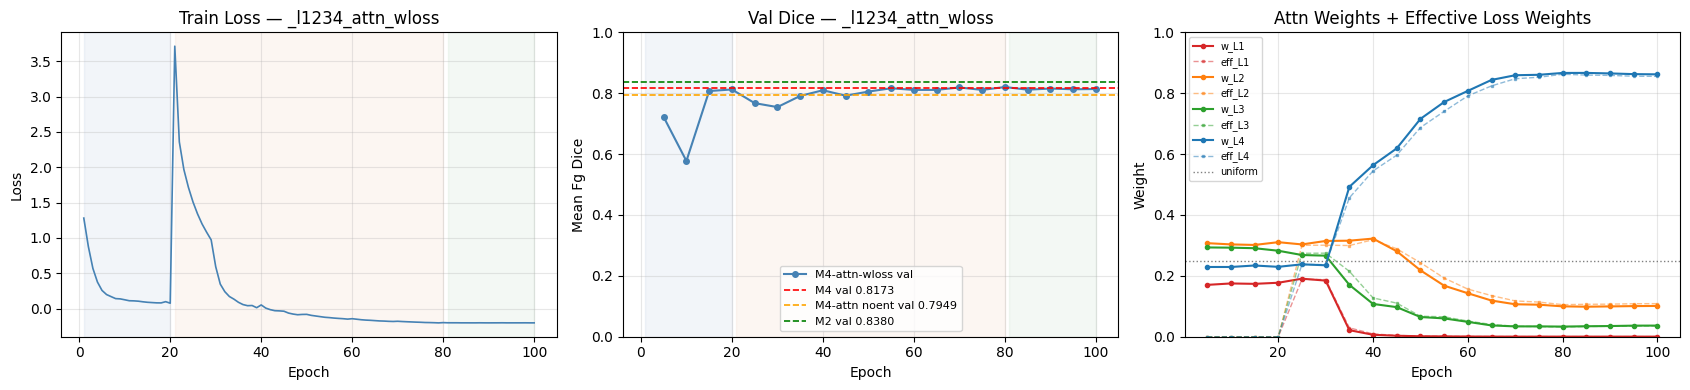

Best val Dice: 0.8203


In [6]:
import pandas as pd

log = pd.read_csv(LOG_PATH)
val = log.dropna(subset=["val_mean_fg_dice"])
attn = pd.read_csv(ATTN_LOG)

M4_3D = 0.8407
M4ATTN_3D = 0.8416  # M4-attn noent baseline
M2_3D = 0.8722
V1_VAL = 0.8173  # M4 best val Dice
NOENT_VAL = 0.7949  # M4-attn noent best val Dice
PHASE_COLORS = {"A": "#4C72B0", "B": "#DD8452", "C": "#55A868"}
LEVEL_COLORS = ["#d62728", "#ff7f0e", "#2ca02c", "#1f77b4"]

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax in axes[:2]:
    for ph, color in PHASE_COLORS.items():
        mask = log["phase"] == ph
        if mask.any():
            ep = log.loc[mask, "epoch"]
            ax.axvspan(ep.min(), ep.max(), alpha=0.07, color=color)

# Left: train loss
axes[0].plot(log["epoch"], log["train_loss"], lw=1.2, color="steelblue")
axes[0].set(title=f"Train Loss — {SUFFIX}", xlabel="Epoch", ylabel="Loss")
axes[0].grid(alpha=0.3)

# Middle: val Dice vs baselines
axes[1].plot(
    val["epoch"],
    val["val_mean_fg_dice"],
    "o-",
    ms=4,
    lw=1.5,
    color="steelblue",
    label="M4-attn-wloss val",
)
axes[1].axhline(V1_VAL, color="red", ls="--", lw=1.2, label=f"M4 val {V1_VAL:.4f}")
axes[1].axhline(
    NOENT_VAL,
    color="orange",
    ls="--",
    lw=1.2,
    label=f"M4-attn noent val {NOENT_VAL:.4f}",
)
axes[1].axhline(0.8380, color="green", ls="--", lw=1.2, label=f"M2 val 0.8380")
axes[1].set(
    title=f"Val Dice — {SUFFIX}", xlabel="Epoch", ylabel="Mean Fg Dice", ylim=(0, 1.0)
)
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8)

# Right: attention weight evolution + effective loss weights
ax = axes[2]
for i, l in enumerate(PROTO_LEVELS):
    col = f"w_L{l}"
    if col in attn.columns:
        ax.plot(
            attn["epoch"],
            attn[col],
            "o-",
            ms=3,
            lw=1.5,
            color=LEVEL_COLORS[i],
            label=f"w_L{l}",
        )
    eff_col = f"eff_w_L{l}"
    if eff_col in attn.columns:
        ax.plot(
            attn["epoch"],
            attn[eff_col],
            "s--",
            ms=2,
            lw=1.0,
            color=LEVEL_COLORS[i],
            alpha=0.5,
            label=f"eff_L{l}",
        )
ax.axhline(1 / len(PROTO_LEVELS), color="gray", ls=":", lw=1, label="uniform")
ax.set(
    title="Attn Weights + Effective Loss Weights",
    xlabel="Epoch",
    ylabel="Weight",
    ylim=(0, 1),
)
ax.grid(alpha=0.3)
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f"{LOG_DIR}/train_curve{SUFFIX}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best val Dice: {val['val_mean_fg_dice'].max():.4f}")

## 6. Quick 3D Dice Eval

In [7]:
from src.data.mmwhs_dataset import MMWHSPatientDataset

ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
eval_model = ProtoSegNet(
    n_classes=NUM_CLASSES,
    proto_levels=ckpt["proto_levels"],
    use_level_attention=ckpt.get("use_level_attention", False),
).to(DEVICE)
eval_model.load_state_dict(ckpt["model_state_dict"])
eval_model.eval()
print(
    f"Loaded: epoch {ckpt['epoch']}  best_val {ckpt['best_val_dice']:.4f}  "
    f"use_level_attention={ckpt.get('use_level_attention')}  "
    f"weighted_proto_loss={ckpt.get('weighted_proto_loss')}"
)


@torch.no_grad()
def eval_3d(model, modality):
    ds = MMWHSPatientDataset(DATA_DIR, modality, "test")
    results = {}
    for i in range(len(ds)):
        s = ds[i]
        imgs = s["image"].to(DEVICE)
        logits_all = [model(imgs[si : si + 1])[0].cpu() for si in range(imgs.shape[0])]
        results[s["patient"]] = dice_per_class(torch.cat(logits_all), s["label"])
    return results


results = eval_3d(eval_model, MODALITY)
FG_NAMES = [LABEL_NAMES[c] for c in range(1, NUM_CLASSES)]

M4_3D = 0.8407
M4ATTN_3D = 0.8416
M2_3D = 0.8722

print(f"\n3D Dice — {SUFFIX}")
print(f"{'Patient':<12} {'MeanFg':>7}  " + "  ".join(f"{n[:4]:>5}" for n in FG_NAMES))
print("─" * 75)
all_means = []
for pid, dice in sorted(results.items()):
    mfg = mean_foreground_dice(dice)
    all_means.append(mfg)
    vals = "  ".join(f"{dice.get(n, float('nan')):>5.3f}" for n in FG_NAMES)
    print(f"{pid:<12} {mfg:>7.4f}  {vals}")
overall = np.mean(all_means)
print("─" * 75)
print(f"{'Mean':<12} {overall:>7.4f}")
print(f"\nΔ vs M4 ({M4_3D:.4f}):       {overall - M4_3D:+.4f}")
print(f"Δ vs M4-attn-noent ({M4ATTN_3D:.4f}): {overall - M4ATTN_3D:+.4f}")
print(f"Δ vs M2 ({M2_3D:.4f}):       {overall - M2_3D:+.4f}")

# RQ6 preliminary check (full analysis in notebook 24)
print(f"\nRQ6 Dice criterion: 3D Dice ≥ {M4ATTN_3D:.4f} (must not regress)")
print("✅ passes" if overall >= M4ATTN_3D else "⚠️ regressed vs M4-attn noent")

Loaded: epoch 80  best_val 0.8203  use_level_attention=True  weighted_proto_loss=True

3D Dice — _l1234_attn_wloss
Patient       MeanFg     LV     RV     LA     RA   Myoc   Aort     PA
───────────────────────────────────────────────────────────────────────────
ct_1019       0.7613  0.868  0.859  0.801  0.885  0.748  0.615  0.553
ct_1020       0.9337  0.896  0.959  0.942  0.906  0.927  0.976  0.929
───────────────────────────────────────────────────────────────────────────
Mean          0.8475

Δ vs M4 (0.8407):       +0.0068
Δ vs M4-attn-noent (0.8416): +0.0059
Δ vs M2 (0.8722):       -0.0247

RQ6 Dice criterion: 3D Dice ≥ 0.8416 (must not regress)
✅ passes
